# Data Integrity and Experimental Framing for ADFA-LD

Reliable intrusion-detection research begins with a rigorous audit of data validity, split integrity, and protocol realism. This study examines ADFA-LD before any model training to ensure that reported performance reflects genuine generalisation rather than artefacts introduced by leakage or weak split design.

The guiding scientific question is whether ADFA-LD can support a credible host-based detection benchmark under scenario-level generalisation constraints. To answer this, the analysis establishes reproducible split logic, quantifies structural properties of the corpus, and validates anti-leakage guarantees at both trace and content-hash levels.

This framing is essential because security datasets often contain repeated behaviours and hidden dependencies that can inflate evaluation scores if not explicitly controlled.

## Protocol Design and Generalisation Logic

Three complementary protocols are defined to separate methodological objectives. The scenario-based protocol is treated as primary because it evaluates performance on attack contexts not seen during model development. A stratified split is retained as a comparative sanity reference, while a held-out-family design probes zero-shot transfer to families excluded from training.

| Protocol | Purpose | Core rule |
|---|---|---|
| Scenario-based | Primary scientific evaluation | Train scenarios 1-7, validate on 8, test on 9-10 |
| Stratified binary | Comparative baseline | Random 70/15/15 with label stratification |
| Held-out family | Zero-shot stress test | Exclude Web_Shell and Meterpreter from train |

This structure avoids the common error of conflating interpolation with generalisation. Under realistic deployment assumptions, the relevant question is not whether a model recognises a known attack variant, but whether it preserves decision quality when threat expression changes.

In [19]:
from pathlib import Path
import importlib
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src.data_loading as data_loading
importlib.reload(data_loading)

assign_protocol_baseline_binary = data_loading.assign_protocol_baseline_binary
assign_protocol_heldout_families = data_loading.assign_protocol_heldout_families
assign_protocol_main = data_loading.assign_protocol_main
build_scenario_cv_folds = data_loading.build_scenario_cv_folds
dataset_audit_report = data_loading.dataset_audit_report
discover_adfa_samples = data_loading.discover_adfa_samples
enforce_sha1_disjoint_splits = data_loading.enforce_sha1_disjoint_splits
leakage_report = data_loading.leakage_report

from src.utils import METADATA_ROOT, RAW_ROOT, ensure_dir

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'default.yaml'
with CONFIG_PATH.open('r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

heldout_families = cfg['protocols']['heldout_families']['families']
print('Held-out families from config:', heldout_families)

sns.set_theme(style='whitegrid', context='talk')

Held-out families from config: ['Web_Shell', 'Meterpreter']


In [20]:
raw_adfa_root = RAW_ROOT / 'adfa-ld'
base_df = discover_adfa_samples(raw_adfa_root, load_sequences=False, strict=True)

print('Colonnes metadata:', list(base_df.columns))
print('Total traces:', len(base_df))
display(base_df.head(3))

Colonnes metadata: ['trace_id', 'filepath', 'rel_path', 'source_split', 'split_origin', 'attack_family', 'attack_scenario', 'label', 'label_binary', 'length', 'sha1', 'is_empty', 'has_parse_error', 'parse_error']
Total traces: 5951


,trace_id,filepath,rel_path,source_split,split_origin,attack_family,attack_scenario,label,label_binary,length,sha1,is_empty,has_parse_error,parse_error
0,T_45f8f1d3b4d8,C:\Users\223114186\Desktop\System_Call_Based_I...,Attack_Data_Master\Adduser_10\UAD-Adduser-10-1...,attack,attack,Adduser,10.0,attack,1,239,60f431c6b553130b596f7453a7ef65480d312c08,False,False,
1,T_987315f46250,C:\Users\223114186\Desktop\System_Call_Based_I...,Attack_Data_Master\Adduser_10\UAD-Adduser-10-1...,attack,attack,Adduser,10.0,attack,1,735,952e621016fd40cbd5f4385302d4820d48a5f38e,False,False,
2,T_e21193d96f6f,C:\Users\223114186\Desktop\System_Call_Based_I...,Attack_Data_Master\Adduser_10\UAD-Adduser-10-2...,attack,attack,Adduser,10.0,attack,1,691,6a1007374b251dcdc352a2e84cf5ef78772d2983,False,False,


In [22]:
metadata_df = discover_adfa_samples(raw_adfa_root)

protocol_a_df = assign_protocol_main(metadata_df)
protocol_b_df = assign_protocol_baseline_binary(metadata_df)
protocol_c_df = assign_protocol_heldout_families(metadata_df, heldout_families=heldout_families)

# Enforce content-hash disjointness to avoid duplicate-content leakage across splits.
protocol_a_df = enforce_sha1_disjoint_splits(protocol_a_df)
protocol_b_df = enforce_sha1_disjoint_splits(protocol_b_df)
protocol_c_df = enforce_sha1_disjoint_splits(protocol_c_df)

cv_folds = build_scenario_cv_folds(metadata_df)

def role_table(df, name):
    return (
        df.groupby(['split', 'label'])['trace_id']
        .count()
        .rename('count')
        .reset_index()
        .assign(protocol=name)
    )

protocol_role_summary = pd.concat(
    [
        role_table(protocol_a_df, 'A_main'),
        role_table(protocol_b_df, 'B_binary'),
        role_table(protocol_c_df, 'C_heldout'),
    ],
    ignore_index=True,
 )

display(protocol_role_summary)

,split,label,count,protocol
0,test,attack,165,A_main
1,test,normal,1121,A_main
2,train,attack,510,A_main
3,train,normal,1256,A_main
4,val,attack,71,A_main
5,val,normal,2828,A_main
6,test,attack,107,B_binary
7,test,normal,415,B_binary
8,train,attack,528,B_binary
9,train,normal,4354,B_binary


In [23]:
display(protocol_a_df.groupby('attack_family').size().rename('count').reset_index().sort_values('count', ascending=False))
display(protocol_a_df[['length']].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

leak = leakage_report(protocol_a_df)
print('Leakage report (Protocol A):')
print(json.dumps(leak, indent=2))

def overlap_count_by_split(df, key_col, split_a, split_b):
    set_a = set(df[df['split'] == split_a][key_col].dropna().tolist())
    set_b = set(df[df['split'] == split_b][key_col].dropna().tolist())
    return len(set_a.intersection(set_b))

split_pairs = [('train', 'val'), ('train', 'test'), ('val', 'test')]
explicit_sha1_checks = []
explicit_trace_checks = []
for a, b in split_pairs:
    explicit_sha1_checks.append({'pair': f'{a}-{b}', 'sha1_overlap_count': overlap_count_by_split(protocol_a_df, 'sha1', a, b)})
    explicit_trace_checks.append({'pair': f'{a}-{b}', 'trace_id_overlap_count': overlap_count_by_split(protocol_a_df, 'trace_id', a, b)})

print('Verification explicite anti-leakage par sha1 entre train/val/test')
display(pd.DataFrame(explicit_sha1_checks))
print('Verification explicite anti-leakage par trace_id entre train/val/test')
display(pd.DataFrame(explicit_trace_checks))

,attack_family,count
2,Hydra_SSH,176
1,Hydra_FTP,162
3,Java_Meterpreter,124
5,Web_Shell,118
0,Adduser,91
4,Meterpreter,75


,length
count,5951.000000
mean,461.695513
std,521.890584
min,75.000000
50%,343.000000
90%,1136.000000
95%,1576.000000
99%,2758.500000
max,4494.000000


Leakage report (Protocol A):
{
  "duplicate_trace_id": 0,
  "duplicate_sha1": 2099,
  "sha1_shared_across_splits": 0,
  "family_split_table": [
    {
      "split": "test",
      "attack_family": "Adduser",
      "count": 28
    },
    {
      "split": "test",
      "attack_family": "Hydra_FTP",
      "count": 35
    },
    {
      "split": "test",
      "attack_family": "Hydra_SSH",
      "count": 38
    },
    {
      "split": "test",
      "attack_family": "Java_Meterpreter",
      "count": 26
    },
    {
      "split": "test",
      "attack_family": "Meterpreter",
      "count": 12
    },
    {
      "split": "test",
      "attack_family": "Web_Shell",
      "count": 26
    },
    {
      "split": "train",
      "attack_family": "Adduser",
      "count": 56
    },
    {
      "split": "train",
      "attack_family": "Hydra_FTP",
      "count": 115
    },
    {
      "split": "train",
      "attack_family": "Hydra_SSH",
      "count": 119
    },
    {
      "split": "train",
      

,pair,sha1_overlap_count
0,train-val,0
1,train-test,0
2,val-test,0


Verification explicite anti-leakage par trace_id entre train/val/test


,pair,trace_id_overlap_count
0,train-val,0
1,train-test,0
2,val-test,0


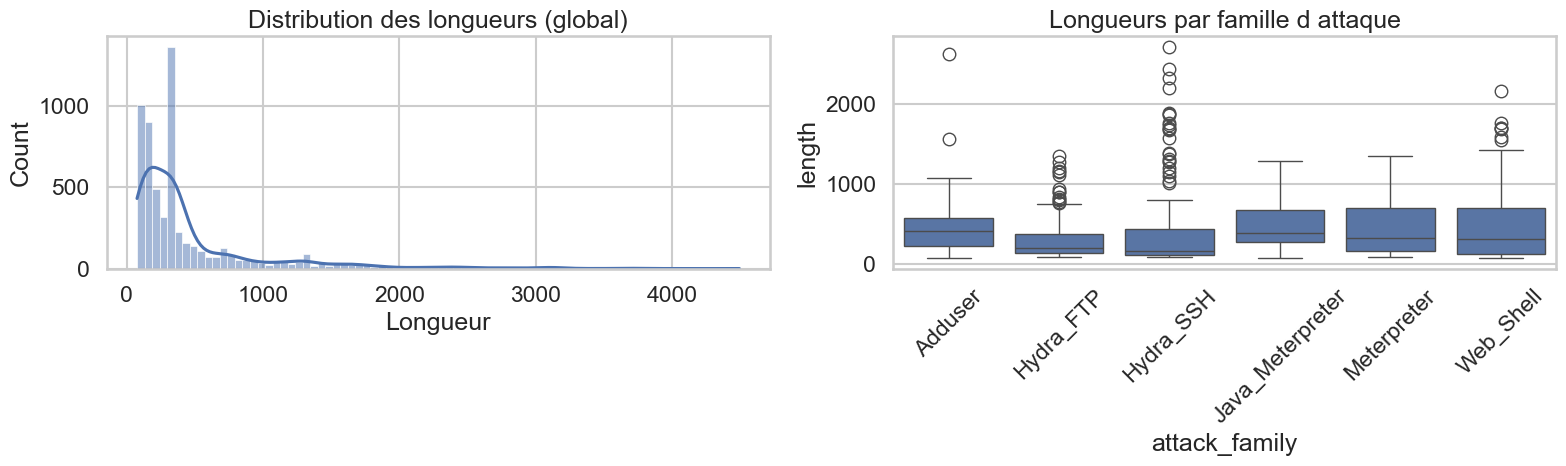

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(protocol_a_df[protocol_a_df['length'] >= 0], x='length', bins=80, kde=True, ax=axes[0])
axes[0].set_title('Distribution des longueurs (global)')
axes[0].set_xlabel('Longueur')

sns.boxplot(data=protocol_a_df[protocol_a_df['label'] == 'attack'], x='attack_family', y='length', ax=axes[1])
axes[1].set_title('Longueurs par famille d attaque')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()

## Empirical Profile of the Corpus

The dataset exhibits strong class asymmetry, with normal behaviour dominating attack traces by approximately seven to one. This imbalance immediately limits the interpretability of accuracy and justifies the use of F1, PR-AUC, false-positive rate, and false-negative rate as operational metrics.

Family-level heterogeneity is also pronounced. Brute-force families are comparatively frequent and regular, whereas Adduser and Meterpreter present lower support and broader variance. This composition anticipates non-uniform error behaviour and motivates subgroup analysis later in the pipeline.

Sequence lengths are right-skewed, with a long upper tail. The observed distribution supports percentile-based truncation derived from training data only, which preserves methodological separation between preprocessing and evaluation.

Finally, duplicate-content traces are non-negligible in ADFA-LD. After SHA-1 based split sanitisation, cross-split overlap is removed, ensuring that identical content does not appear in both development and evaluation partitions.

In [25]:
ensure_dir(METADATA_ROOT)
protocol_a_path = METADATA_ROOT / 'adfa_sample_index_protocol_a.csv'
protocol_b_path = METADATA_ROOT / 'adfa_sample_index_protocol_b.csv'
protocol_c_path = METADATA_ROOT / 'adfa_sample_index_protocol_c.csv'
audit_path = METADATA_ROOT / 'adfa_audit_report.json'
split_ratio_path = METADATA_ROOT / 'adfa_split_ratio_protocol_a.csv'
scenario_split_path = METADATA_ROOT / 'adfa_attack_scenario_split_protocol_a.csv'
leak_sha1_path = METADATA_ROOT / 'adfa_leakage_sha1_checks.csv'
leak_trace_path = METADATA_ROOT / 'adfa_leakage_traceid_checks.csv'

if protocol_a_df.empty or protocol_b_df.empty or protocol_c_df.empty:
    raise ValueError('Refus de sauvegarder: au moins un index de protocole est vide')

protocol_a_df.to_csv(protocol_a_path, index=False)
protocol_b_df.to_csv(protocol_b_path, index=False)
protocol_c_df.to_csv(protocol_c_path, index=False)

split_ratio_df = ratio_tbl.reset_index()
scenario_split_df = scenario_split_tbl.copy()
sha1_df = pd.DataFrame(explicit_sha1_checks)
trace_df = pd.DataFrame(explicit_trace_checks)

if split_ratio_df.empty or scenario_split_df.empty:
    raise ValueError('Refus de sauvegarder: tables de controle vides')

split_ratio_df.to_csv(split_ratio_path, index=False)
scenario_split_df.to_csv(scenario_split_path, index=False)
sha1_df.to_csv(leak_sha1_path, index=False)
trace_df.to_csv(leak_trace_path, index=False)

audit_report = dataset_audit_report(protocol_a_df)
with audit_path.open('w', encoding='utf-8') as f:
    json.dump(audit_report, f, indent=2, ensure_ascii=True)

for scenario_id, fold_df in cv_folds.items():
    fold_path = METADATA_ROOT / f'adfa_cv_fold_{scenario_id:02d}.csv'
    if fold_df.empty:
        raise ValueError(f'Refus de sauvegarder fold vide: {scenario_id}')
    fold_df.to_csv(fold_path, index=False)

print('Saved:', protocol_a_path)
print('Saved:', protocol_b_path)
print('Saved:', protocol_c_path)
print('Saved:', split_ratio_path)
print('Saved:', scenario_split_path)
print('Saved:', leak_sha1_path)
print('Saved:', leak_trace_path)
print('Saved:', audit_path)

Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\data\metadata\adfa_sample_index_protocol_a.csv
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\data\metadata\adfa_sample_index_protocol_b.csv
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\data\metadata\adfa_sample_index_protocol_c.csv
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\data\metadata\adfa_split_ratio_protocol_a.csv
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\data\metadata\adfa_attack_scenario_split_protocol_a.csv
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\data\metadata\adfa_leakage_sha1_checks.csv
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\data\metadata\adfa_leakage_t

## Consolidated Findings and Methodological Consequences

The audit confirms that the dataset can support a defensible intrusion-detection benchmark when protocol constraints are enforced explicitly. Sequence files are valid, split assignment is reproducible, and leakage controls remove both trace-identifier and content-hash contamination across partitions.

These guarantees are not administrative details; they define the scientific validity of every downstream result. By freezing protocol indices at this stage, all subsequent modelling steps inherit the same experimental foundation, enabling fair comparison across representation families and learning algorithms.

The next stage therefore focuses on representation construction under strict train-only fitting rules, preserving the separation between data preparation and model evaluation.